# DEA
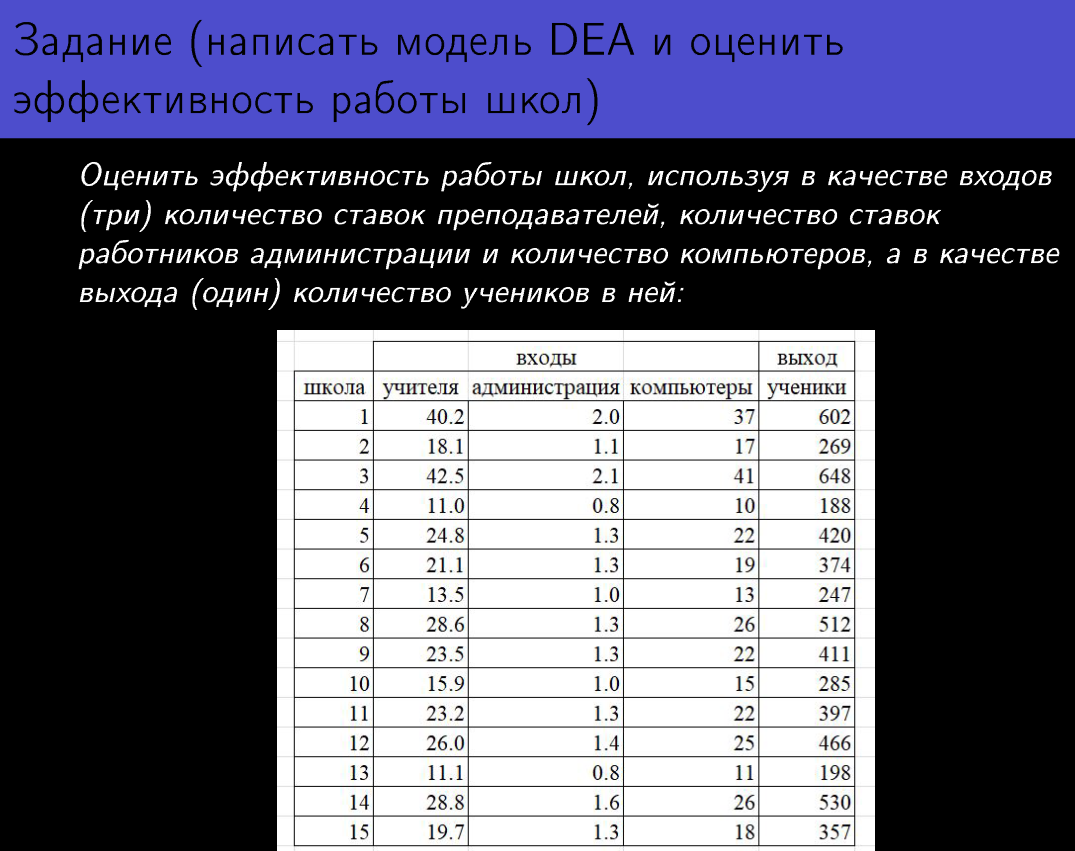

In [2]:
import pandas as pd
import numpy as np
from scipy.optimize import linprog

# 1. Создаем данные из таблицы на картинке
data = {
    'school': list(range(1, 16)),
    'teachers': [40.2, 18.1, 42.5, 11.0, 24.8, 21.1, 13.5, 28.6, 23.5, 15.9, 23.2, 26.0, 11.1, 28.8, 19.7],
    'admin':    [2.0,  1.1,  2.1,  0.8,  1.3,  1.3,  1.0,  1.3,  1.3,  1.0,  1.3,  1.4,  0.8,  1.6,  1.3],
    'computers':[37,   17,   41,   10,   22,   19,   13,   26,   22,   15,   22,   25,   11,   26,   18],
    'students': [602,  269,  648,  188,  420,  374,  247,  512,  411,  285,  397,  466,  198,  530,  357]
}

df = pd.DataFrame(data)

# Разделяем на матрицу входов (X) и вектор выходов (Y)
# Входы: учителя, администрация, компьютеры
X = df[['teachers', 'admin', 'computers']].values
# Выход: ученики
Y = df[['students']].values

n_dmu = len(df)       # Количество школ (15)
n_inputs = X.shape[1] # Количество входов (3)
n_outputs = Y.shape[1]# Количество выходов (1)

efficiency_scores = []

# 2. Решаем задачу линейного программирования для каждой школы (DMU)
for k in range(n_dmu):
    # Целевая функция: Минимизировать theta (эффективность)
    # Переменные: [lambda_1 ... lambda_15, theta]
    # c = [0, 0, ..., 0, 1]
    c = np.zeros(n_dmu + 1)
    c[-1] = 1.0 
    
    # Ограничения (A_ub * x <= b_ub)
    # Формулировка задачи (Envelopment form, Input-oriented):
    # 1. sum(lambda_j * x_ij) <= theta * x_ik  =>  sum(lambda_j * x_ij) - theta * x_ik <= 0
    # 2. sum(lambda_j * y_rj) >= y_rk          => -sum(lambda_j * y_rj) <= -y_rk
    
    A_ub = []
    b_ub = []
    
    # Ограничения по входам (3 ограничения)
    for i in range(n_inputs):
        row = list(X[:, i]) # Коэффициенты при lambda
        row.append(-X[k, i]) # Коэффициент при theta (-x_ik)
        A_ub.append(row)
        b_ub.append(0)
        
    # Ограничения по выходам (1 ограничение)
    for r in range(n_outputs):
        row = [-y for y in Y[:, r]] # Коэффициенты при lambda (со знаком минус)
        row.append(0) # Theta не участвует в ограничении выхода для input-oriented модели
        A_ub.append(row)
        b_ub.append(-Y[k, r])
        
    A_ub = np.array(A_ub)
    b_ub = np.array(b_ub)
    
    # Границы переменных: lambda >= 0, theta не ограничена (но по смыслу > 0)
    # В linprog по умолчанию переменные >= 0. Theta может быть любой, но в DEA она обычно > 0.
    # Оставим theta свободной (None, None), хотя на практике она будет положительной.
    bounds = [(0, None)] * n_dmu + [(None, None)]
    
    # Решаем
    res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')
    
    if res.success:
        efficiency_scores.append(res.x[-1]) # Последняя переменная - это theta
    else:
        efficiency_scores.append(np.nan)

# 3. Добавляем результаты в таблицу
df['Efficiency_Score'] = efficiency_scores
df['Is_Efficient'] = df['Efficiency_Score'].apply(lambda x: 'Да' if abs(x - 1.0) < 1e-5 else 'Нет')

# Округляем для красоты
pd.set_option('display.precision', 4)
print("Результаты оценки эффективности школ (Модель CCR):")
display(df[['school', 'teachers', 'admin', 'computers', 'students', 'Efficiency_Score', 'Is_Efficient']])

# Вывод статистики
print(f"\nЭффективных школ: {len(df[df['Is_Efficient'] == 'Да'])} из {n_dmu}")
print(f"Средняя эффективность: {df['Efficiency_Score'].mean():.4f}")

Результаты оценки эффективности школ (Модель CCR):


,school,teachers,admin,computers,students,Efficiency_Score,Is_Efficient
0,1,40.2,2.0,37,602,0.8267,Нет
1,2,18.1,1.1,17,269,0.8076,Нет
2,3,42.5,2.1,41,648,0.8425,Нет
3,4,11.0,0.8,10,188,0.9287,Нет
4,5,24.8,1.3,22,420,0.9433,Нет
5,6,21.1,1.3,19,374,0.9656,Нет
6,7,13.5,1.0,13,247,0.9942,Нет
7,8,28.6,1.3,26,512,1.0000,Да
8,9,23.5,1.3,22,411,0.9510,Нет
9,10,15.9,1.0,15,285,0.9740,Нет



Эффективных школ: 2 из 15
Средняя эффективность: 0.9397


# DEA и Кохонен
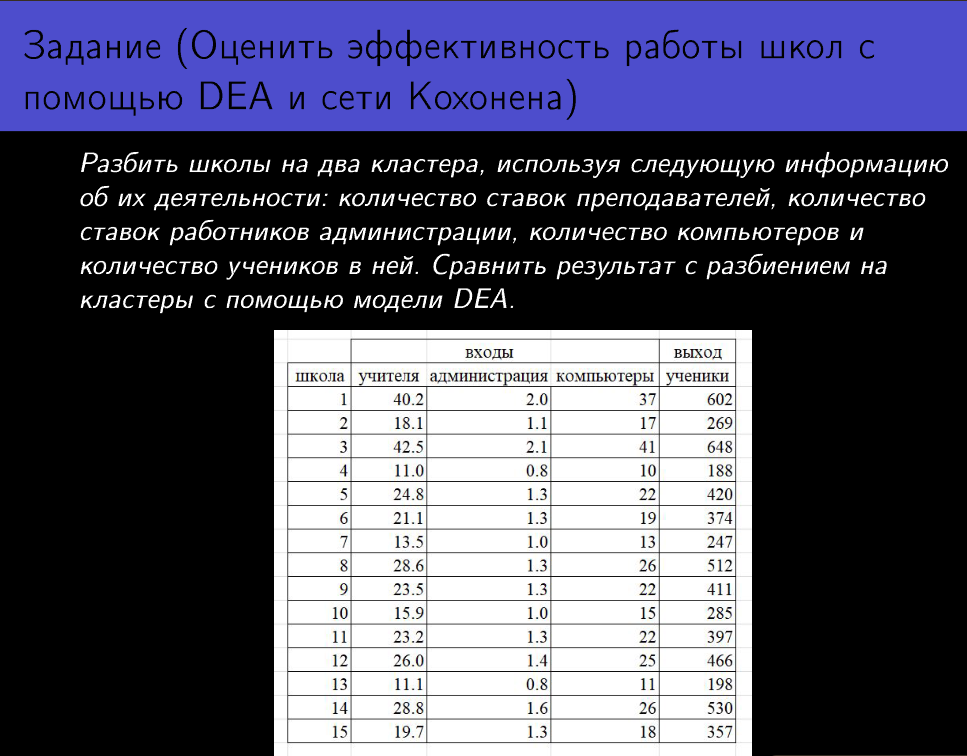

In [1]:
import pandas as pd
import numpy as np
from scipy.optimize import linprog

data = {
    'school': list(range(1, 16)),
    'teachers':    [40.2, 18.1, 42.5, 11.0, 24.8, 21.1, 13.5, 28.6, 23.5, 15.9, 23.2, 26.0, 11.1, 28.8, 19.7],
    'admin':       [2.0,  1.1,  2.1,  0.8,  1.3,  1.3,  1.0,  1.3,  1.3,  1.0,  1.3,  1.4,  0.8,  1.6,  1.3],
    'computers':   [37,   17,   41,   10,   22,   19,   13,   26,   22,   15,   22,   25,   11,   26,   18],
    'students':    [602,  269,  648,  188,  420,  374,  247,  512,  411,  285,  397,  466,  198,  530,  357]
}

df = pd.DataFrame(data)

# Данные для DEA (Входы и Выходы)
# Входы: учителя, администрация, компьютеры
X_dea = df[['teachers', 'admin', 'computers']].values
# Выход: ученики
Y_dea = df[['students']].values

# Данные для Кохонена (Все 4 признака как вектор характеристик)
# X_koh = [teachers, admin, computers, students]
X_koh_raw = df[['teachers', 'admin', 'computers', 'students']].values

# 2. DEA
n_dmu = len(df)
n_inputs = X_dea.shape[1]
n_outputs = Y_dea.shape[1]

dea_scores = []

for k in range(n_dmu):
    # Целевая функция: минимизировать theta
    c = np.zeros(n_dmu + 1)
    c[-1] = 1.0 
    
    # Ограничения
    A_ub = []
    b_ub = []
    
    # Ограничения по входам: sum(lambda * x) <= theta * x_k
    for i in range(n_inputs):
        row = list(X_dea[:, i])
        row.append(-X_dea[k, i])
        A_ub.append(row)
        b_ub.append(0)
        
    # Ограничения по выходам: sum(lambda * y) >= y_k  => -sum(lambda * y) <= -y_k
    for r in range(n_outputs):
        row = [-y for y in Y_dea[:, r]]
        row.append(0)
        A_ub.append(row)
        b_ub.append(-Y_dea[k, r])
        
    A_ub = np.array(A_ub)
    b_ub = np.array(b_ub)
    
    bounds = [(0, None)] * n_dmu + [(None, None)]
    
    res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')
    
    if res.success:
        dea_scores.append(res.x[-1])
    else:
        dea_scores.append(np.nan)

df['DEA_Score'] = dea_scores
# Кластеризация по DEA: 1.0 = Эффективные, <1.0 = Неэффективные
df['DEA_Cluster'] = df['DEA_Score'].apply(lambda x: 'Эффективные' if abs(x - 1.0) < 1e-5 else 'Неэффективные')

# 3. Сеть Кохонена

# 3.1 Нормализация данных (Min-Max к [0, 1])
# Это необходимо, чтобы признаки с большими числами (ученики) не доминировали
min_vals = X_koh_raw.min(axis=0)
max_vals = X_koh_raw.max(axis=0)
X_koh_norm = (X_koh_raw - min_vals) / (max_vals - min_vals)

# Параметры алгоритма
K = 2  # Количество кластеров
N = X_koh_norm.shape[1] # Размерность (4 признака)
M = X_koh_norm.shape[0] # Количество объектов (15)

# Инициализация весов W (случайные центры из данных)
np.random.seed(42)
indices = np.random.choice(M, K, replace=False)
W = X_koh_norm[indices].copy() # W имеет размер (2, 4)

# Параметры обучения
lambda_start = 0.5
delta_lambda = 0.05
lambda_curr = lambda_start
inner_repeats = 10 # "Повтор шагов 3-4 фиксированное число раз"

print("Начало обучения сети Кохонена...")

# Основной цикл (Пока lambda > 0)
while lambda_curr > 0:
    # Повтор шагов 3-4 фиксированное число раз (Эпохи)
    for _ in range(inner_repeats):
        # Для каждого объекта X^m (можно в случайном порядке, здесь последовательно)
        # Создаем перемешанные индексы для стохастичности
        indices_shuffle = np.random.permutation(M)
        
        for idx in indices_shuffle:
            x_m = X_koh_norm[idx]
            
            # Шаг 3: Находим ближайший W^k (Евклидово расстояние)
            distances = np.linalg.norm(W - x_m, axis=1)
            winner_idx = np.argmin(distances)
            
            # Шаг 4: Изменяем найденный вектор
            # W^k := W^k + lambda * (X^m - W^k)
            W[winner_idx] = W[winner_idx] + lambda_curr * (x_m - W[winner_idx])
    
    # Шаг 5: Меняем скорость обучения
    lambda_curr = lambda_curr - delta_lambda

print("Обучение завершено.")

# 3.2 Присвоение кластеров объектам
kohonen_clusters = []
for i in range(M):
    x_m = X_koh_norm[i]
    distances = np.linalg.norm(W - x_m, axis=1)
    cluster_id = np.argmin(distances)
    kohonen_clusters.append(f"Кластер {cluster_id + 1}")

df['Kohonen_Cluster'] = kohonen_clusters

# 3.3 Обратная нормировка весов
# W_real = W_norm * (max - min) + min
W_real = W * (max_vals - min_vals) + min_vals

print("\nЦентры кластеров (средние характеристики после обратной нормировки):")
centers_df = pd.DataFrame(W_real, columns=['teachers', 'admin', 'computers', 'students'])
centers_df['Cluster'] = ['Кластер 1', 'Кластер 2']
print(centers_df)

# 4. Сравнение
print("\nСводная таблица результатов")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
# Выбираем нужные колонки для вывода
result_cols = ['school', 'teachers', 'students', 'DEA_Score', 'DEA_Cluster', 'Kohonen_Cluster']
print(df[result_cols])

# Анализ совпадений
print("\nАнализ соответствия кластеров")
# Какие школы попали в кластеры Кохонена и каков их статус DEA
for k in [1, 2]:
    mask = df['Kohonen_Cluster'] == f'Кластер {k}'
    subset = df[mask]
    eff_count = len(subset[subset['DEA_Cluster'] == 'Эффективные'])
    ineff_count = len(subset[subset['DEA_Cluster'] == 'Неэффективные'])
    print(f"{f'Кластер {k}'} (Количество школ: {len(subset)}):")
    print(f"  - Эффективных по DEA: {eff_count}")
    print(f"  - Неэффективных по DEA: {ineff_count}")
    print(f"  - Средний размер (ученики): {subset['students'].mean():.1f}")

Начало обучения сети Кохонена...
Обучение завершено.

Центры кластеров (средние характеристики после обратной нормировки):
    teachers     admin  computers    students    Cluster
0  18.277639  1.123163  16.979296  315.592575  Кластер 1
1  33.389854  1.687562  31.146968  553.159503  Кластер 2

Сводная таблица результатов
    school  teachers  students  DEA_Score    DEA_Cluster Kohonen_Cluster
0        1      40.2       602   0.826666  Неэффективные       Кластер 2
1        2      18.1       269   0.807589  Неэффективные       Кластер 1
2        3      42.5       648   0.842461  Неэффективные       Кластер 2
3        4      11.0       188   0.928714  Неэффективные       Кластер 1
4        5      24.8       420   0.943331  Неэффективные       Кластер 1
5        6      21.1       374   0.965641  Неэффективные       Кластер 1
6        7      13.5       247   0.994214  Неэффективные       Кластер 1
7        8      28.6       512   1.000000    Эффективные       Кластер 2
8        9      23.5

In [ ]:
print("DEA")
print("_" * 50)

print(f"\nВсего школ: {len(df)}")
print("_" * 50)

print(f"Эффективных (score = 1.0): {len(df[df['DEA_Cluster'] == 'Эффективные'])}")
print(f"Неэффективных (score < 1.0): {len(df[df['DEA_Cluster'] == 'Неэффективные'])}")

print("\nЭффективные школы (DEA Score = 1.0):")
efficient_schools = df[df['DEA_Cluster'] == 'Эффективные']['school'].tolist()
print(f"Номера школ: {efficient_schools}")
print(df[df['DEA_Cluster'] == 'Эффективные'][['school', 'teachers', 'admin', 'computers', 'students', 'DEA_Score']])

print("\nКохонен")
print("_" * 50)

print(f"\nКластер 1: {len(df[df['Kohonen_Cluster'] == 'Кластер 1'])} школ")
print(f"Кластер 2: {len(df[df['Kohonen_Cluster'] == 'Кластер 2'])} школ")

print("\nСравнение")
print("_" * 50)

crosstab = pd.crosstab(df['DEA_Cluster'], df['Kohonen_Cluster'])
print(crosstab)

DEA

Всего школ: 15
Эффективных (score = 1.0): 2
Неэффективных (score < 1.0): 13

Эффективные школы (DEA Score = 1.0):
Номера школ: [8, 14]
    school  teachers  admin  computers  students  DEA_Score
7        8      28.6    1.3         26       512        1.0
13      14      28.8    1.6         26       530        1.0

Кохонен

Кластер 1: 10 школ
Кластер 2: 5 школ

Сравнение
Kohonen_Cluster  Кластер 1  Кластер 2
DEA_Cluster                          
Неэффективные           10          3
Эффективные              0          2


# kNN
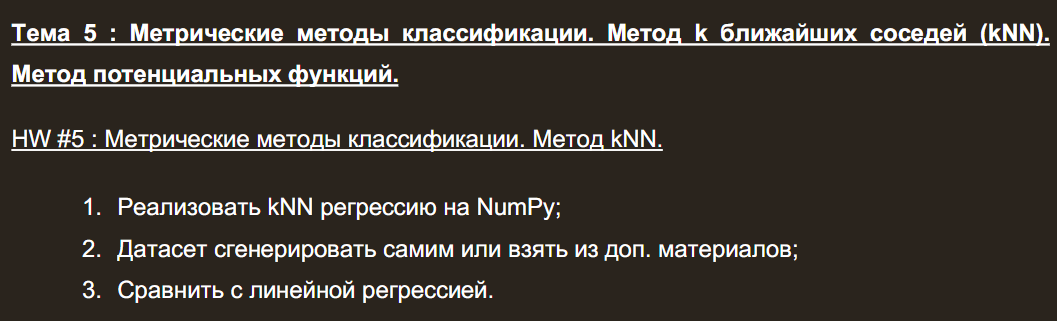

kNN РЕГРЕССИЯ
__________________________________________________
k=1: MSE=0.0186, R²=0.9615
k=3: MSE=0.0113, R²=0.9767
k=5: MSE=0.0113, R²=0.9767
k=10: MSE=0.0119, R²=0.9754
k=15: MSE=0.0124, R²=0.9744

Линейная регрессия
__________________________________________________
MSE=0.5265, R²=-0.0887


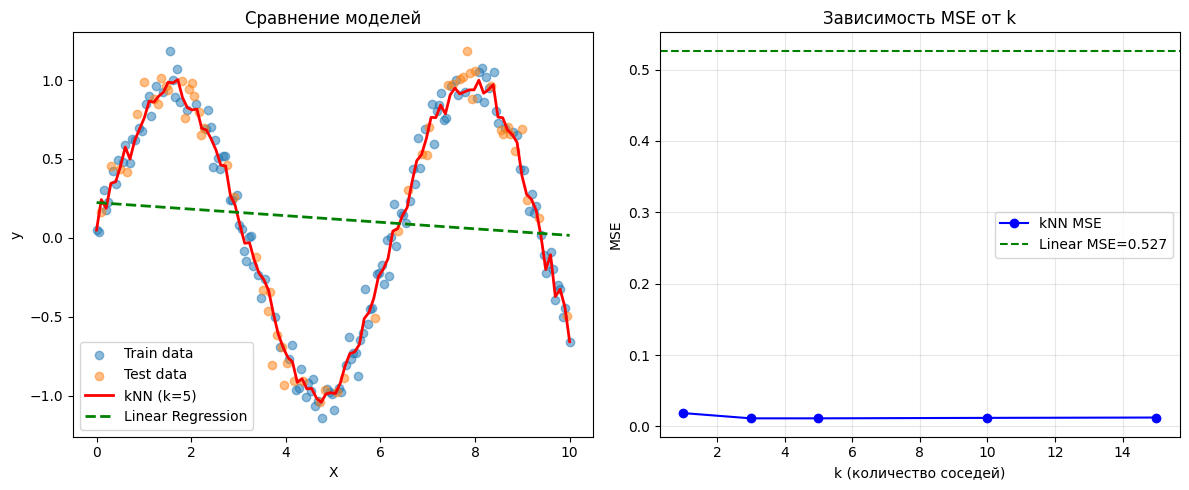


__________________________________________________
Вывод:
Лучший kNN: k=5, MSE=0.0113
Линейная регрессия: MSE=0.5265
✓ kNN работает лучше на этих данных!


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 1. Генерация данных
# Простой нелинейный датасет
np.random.seed(42)
X = np.linspace(0, 10, 200).reshape(-1, 1)
y = np.sin(X.ravel()) + 0.1 * np.random.randn(200)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# 2. Обучение kNN с разными k
print("kNN РЕГРЕССИЯ")
print("_" * 50)

k_values = [1, 3, 5, 10, 15]
results = []

for k in k_values:
    # Создаём и обучаем kNN
    knn = KNeighborsRegressor(n_neighbors=k, weights='distance')
    knn.fit(X_train, y_train)
    
    # Предсказания
    y_pred = knn.predict(X_test)
    
    # Метрики
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({'k': k, 'MSE': mse, 'R2': r2})
    print(f"k={k}: MSE={mse:.4f}, R²={r2:.4f}")

# 3. Линейная регрессия для сравнения
print("\nЛинейная регрессия")
print("_" * 50)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"MSE={mse_lr:.4f}, R²={r2_lr:.4f}")

# 4. Визуализация
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# График 1: Данные и предсказания
axes[0].scatter(X_train, y_train, alpha=0.5, label='Train data')
axes[0].scatter(X_test, y_test, alpha=0.5, label='Test data')

X_plot = np.linspace(0, 10, 100).reshape(-1, 1)
axes[0].plot(X_plot, knn.predict(X_plot), 'r-', linewidth=2, label=f'kNN (k=5)')
axes[0].plot(X_plot, lr.predict(X_plot), 'g--', linewidth=2, label='Linear Regression')
axes[0].set_xlabel('X')
axes[0].set_ylabel('y')
axes[0].set_title('Сравнение моделей')
axes[0].legend()

# График 2: MSE от k
mse_values = [r['MSE'] for r in results]
axes[1].plot(k_values, mse_values, 'bo-', label='kNN MSE')
axes[1].axhline(y=mse_lr, color='g', linestyle='--', label=f'Linear MSE={mse_lr:.3f}')
axes[1].set_xlabel('k (количество соседей)')
axes[1].set_ylabel('MSE')
axes[1].set_title('Зависимость MSE от k')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Вывод
best_knn = min(results, key=lambda x: x['MSE'])
print("\n" + "_" * 50)
print("Вывод:")
print(f"Лучший kNN: k={best_knn['k']}, MSE={best_knn['MSE']:.4f}")
print(f"Линейная регрессия: MSE={mse_lr:.4f}")

if best_knn['MSE'] < mse_lr:
    print("✓ kNN работает лучше на этих данных!")
else:
    print("✓ Линейная регрессия работает лучше!")

# ЛП
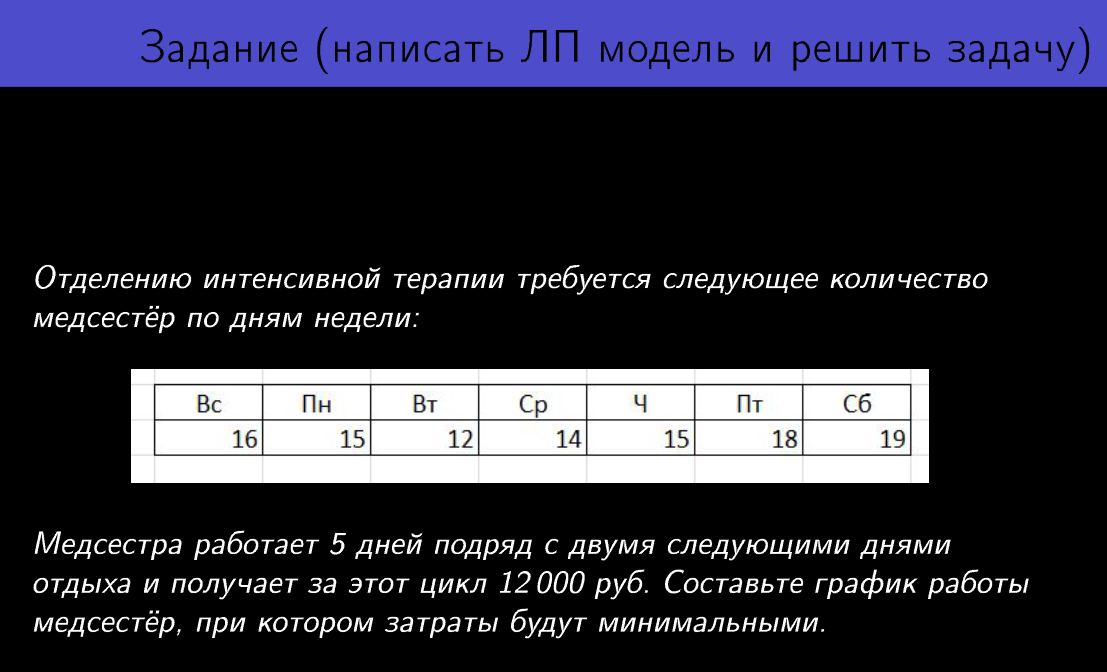

Вводим вектор x из 7 компонент - целые числа - количество медсестёр.

Целевая функция:

сумма компонент (норма x), умноженная на зарплату.

Ограничения:

Создаём расширенный x из 7 + 4 компонент
Создаём матрицу A с единицами в первом столбце в строках начиная с тау до тау + 4 включительно
Суммируем по тау от 1 до 7 произведение матрицы A на расширенный x - это b
Создаём сложенный вектор d, где первые четыре компоненты это суммы b1+b8, b2+ b9 .... остальное как у b
Ограничение - d должен быть больше или равен табличным значениям.

Это учёт цикличности недели. Матрица A создаёт рабочие дни для тех, кто находится в дне тау (от 1 до 7). Потом мы суммируем все получившиеся рабочие дни в расширенный вектор и сжимаем цикличность недель в одну неделю и получаем табличный вид.

Матрицу A потом можно раскрыть.

Но можно сделать и значительно проще заметив, что матрица полностью пустая кроме первого столбца.

In [ ]:
import numpy as np
from scipy.optimize import linprog
import pandas as pd

# Данные
days = ['Вс', 'Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб']
required = np.array([16, 15, 12, 14, 15, 18, 19])

# Матрица ограничений (кто работает в каждый день)
A = np.array([
    [1, 0, 0, 1, 1, 1, 1],  # Вс
    [1, 1, 0, 0, 1, 1, 1],  # Пн
    [1, 1, 1, 0, 0, 1, 1],  # Вт
    [1, 1, 1, 1, 0, 0, 1],  # Ср
    [1, 1, 1, 1, 1, 0, 0],  # Чт
    [0, 1, 1, 1, 1, 1, 0],  # Пт
    [0, 0, 1, 1, 1, 1, 1],  # Сб
])

# Решение
c = np.ones(7) * 12000
res = linprog(c, A_ub=-A, b_ub=-required, bounds=[(0, None)]*7, method='highs')

if res.success:
    x = np.round(res.x).astype(int)
    total_nurses = x.sum()
    total_cost = total_nurses * 12000
    
    # Расчёт фактического количества медсестёр в каждый день
    actual = A @ x
    
    # Создание отчётной таблицы
    report = pd.DataFrame({
        'День недели': days,
        'Требуется': required,
        'Запланировано': actual,
        'Избыток': actual - required,
        'Начинают цикл': x
    })
    
    print(f"\nПоказатели:")
    print(f"   • Общее количество медсестёр: {total_nurses} чел.")
    print(f"   • Минимальные затраты: {total_cost:,} руб.")
    print(f"   • Средняя загрузка: {required.sum() / (total_nurses * 5) * 100:.1f}%")
    
    print(f"\nРаспределение по дням:")
    print(report.to_string(index=False))
    
    print(f"\nАнализ:")
    max_overstaff = (actual - required).max()
    print(f"   • Максимальный избыток медсестёр: {max_overstaff} чел.")
    print(f"   • Дней с точным соответствием: {(actual == required).sum()} из 7")
    print(f"   • Средняя избыточность: {(actual - required).mean():.2f} медсестры/день")
    
    print("\n" + "_" * 70)
else:
    print("Решение не найдено!")


ОБЩИЕ ПОКАЗАТЕЛИ:
   • Общее количество медсестёр: 22 чел.
   • Минимальные затраты: 264,000 руб.
   • Средняя загрузка: 99.1%

Распределение по дням:
День недели  Требуется  Запланировано  Избыток  Начинают цикл
         Вс         16             16        0              0
         Пн         15             15        0              3
         Вт         12             13        1              3
         Ср         14             14        0              4
         Чт         15             15        0              5
         Пт         18             18        0              3
         Сб         19             19        0              4

Анализ:
   • Максимальный избыток медсестёр: 1 чел.
   • Дней с точным соответствием: 6 из 7
   • Средняя избыточность: 0.14 медсестры/день

